# Cardiovascular Disease Risk Prediction
### Cardio-SVM Screener - ML Final Project
**Student:** Abdallah Mohamed Mohamed (231002006)

A binary-classification pipeline that estimates the probability that a
patient has cardiovascular disease from routine vitals and lifestyle answers. The
deployed screener is an **RBF Support Vector Machine**, benchmarked against
K-Nearest Neighbours and XGBoost.

Everything runs from `data/cardio_clean.csv`. The trained pipeline, tuned threshold,
and UI metadata are saved together in a **single** `cardio_svm_bundle.pkl` that the
Flask app in `app.py` loads.

## Step 1 - Project Understanding

**Problem.** Cardiovascular disease (CVD) is the leading cause of death worldwide and
is strongly linked to blood pressure, body composition, cholesterol, and lifestyle.

**Question.** Can we flag likely CVD from cheap, routinely-collected measurements
(age, height, weight, blood pressure, cholesterol/glucose bands, smoking, alcohol,
physical activity) - no imaging, no lab panels beyond simple bands?

**Approach.** Supervised binary classification. We engineer clinical features (BMI,
pulse pressure, mean arterial pressure, ACC/AHA blood-pressure stage), compare three
model families on ROC-AUC, deploy a calibrated RBF SVM, and tune its decision
threshold on F1.

## Step 2 - Imports and Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)

RANDOM_STATE = 2025
MAX_TRAIN_ROWS = 15_000  # SVM-friendly stratified cap
TARGET = 'Cardio'

# Fresh indigo / vermillion palette.
NEG_COLOR = '#4c5fd5'
POS_COLOR = '#e63946'
ACCENT    = '#6a040f'
NEUTRAL   = '#6c757d'
EDGE      = '#1b1b2f'
METRIC_PALETTE = ['#3a0ca3', '#4895ef', '#e63946', '#f9c74f', '#90be6d']
palette = {'No CVD': NEG_COLOR, 'CVD': POS_COLOR}

DATA_PATH = Path('data') / 'cardio_clean.csv'
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

NUMERIC_FEATURES = [
    'Age', 'Height', 'Weight', 'BMI',
    'SystolicBP', 'DiastolicBP', 'PulsePressure', 'MeanArterialPressure',
]
CATEGORICAL_FEATURES = [
    'Gender', 'Cholesterol', 'Glucose', 'Smoker', 'Alcohol',
    'PhysicallyActive', 'BMICategory', 'BPCategory', 'AgeGroup',
]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
print('Features:', len(FEATURE_COLUMNS))

Features: 17


## Step 3 - Load the Dataset

`data/cardio_clean.csv` was produced from the raw `cardio_train.csv` by
`train_cardio_svm.py`: implausible vitals were dropped, coded integers mapped to
readable labels, and clinical features engineered (BMI, pulse pressure, mean arterial
pressure, ACC/AHA blood-pressure stage).

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
df.head()

Rows    : 68,359
Columns : 18


,Cardio,Age,Height,Weight,BMI,SystolicBP,DiastolicBP,PulsePressure,MeanArterialPressure,Gender,Cholesterol,Glucose,Smoker,Alcohol,PhysicallyActive,BMICategory,BPCategory,AgeGroup
0,0,50.4,168.0,62.0,22.0,110.0,80.0,30.0,90.0,Male,Normal,Normal,No,No,Yes,Normal weight,Hypertension stage 1,50-54
1,1,55.4,156.0,85.0,34.9,140.0,90.0,50.0,106.7,Female,Well above normal,Normal,No,No,Yes,Obese,Hypertension stage 2,55-59
2,1,51.6,165.0,64.0,23.5,130.0,70.0,60.0,90.0,Female,Well above normal,Normal,No,No,No,Normal weight,Hypertension stage 1,50-54
3,1,48.2,169.0,82.0,28.7,150.0,100.0,50.0,116.7,Male,Normal,Normal,No,No,Yes,Overweight,Hypertension stage 2,45-49
4,0,47.8,156.0,56.0,23.0,100.0,60.0,40.0,73.3,Female,Normal,Normal,No,No,No,Normal weight,Normal,45-49


In [3]:
print('Target distribution:')
print(df[TARGET].value_counts().rename({0: 'No CVD', 1: 'CVD'}))
print(f"\nPositive class rate: {df[TARGET].mean():.2%}")
print('\nMissing values:', int(df.isna().sum().sum()))

Target distribution:
Cardio
No CVD    34527
CVD       33832
Name: count, dtype: int64

Positive class rate: 49.49%

Missing values: 0


## Step 4 - Exploratory Data Analysis

Target balance, age / BMI / blood-pressure distributions, and how CVD prevalence
rises with cholesterol and blood-pressure stage. Figures are saved into `figures/`.

### 4.1 Target distribution

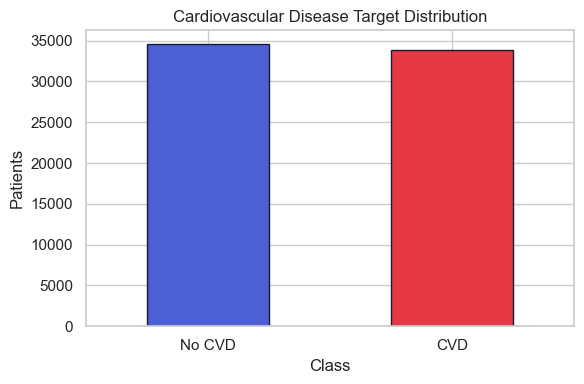

In [4]:
label = df[TARGET].map({0: 'No CVD', 1: 'CVD'})
fig, ax = plt.subplots(figsize=(6, 4))
label.value_counts().reindex(['No CVD', 'CVD']).plot(
    kind='bar', color=[NEG_COLOR, POS_COLOR], edgecolor=EDGE, ax=ax)
ax.set_title('Cardiovascular Disease Target Distribution')
ax.set_xlabel('Class'); ax.set_ylabel('Patients'); ax.tick_params(axis='x', rotation=0)
fig.tight_layout(); fig.savefig(FIG_DIR / '01_target_distribution.png', dpi=150); plt.show()

### 4.2 Age distribution by CVD status

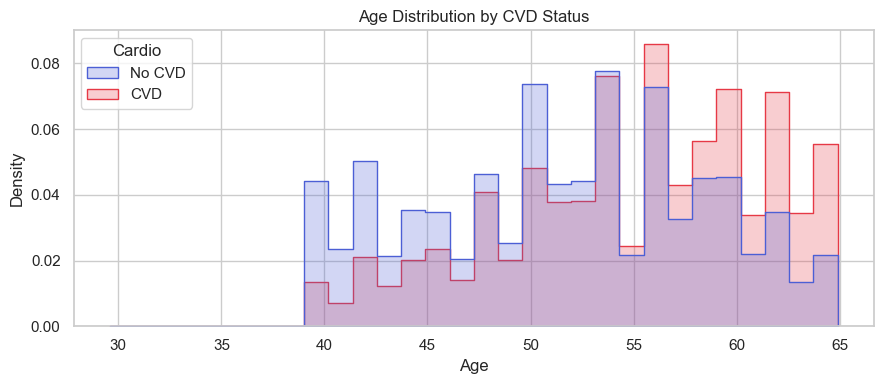

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='Age', hue=label, bins=30, element='step',
             stat='density', common_norm=False, palette=palette, ax=ax)
ax.set_title('Age Distribution by CVD Status')
fig.tight_layout(); fig.savefig(FIG_DIR / '02_age_distribution.png', dpi=150); plt.show()

### 4.3 BMI by CVD status

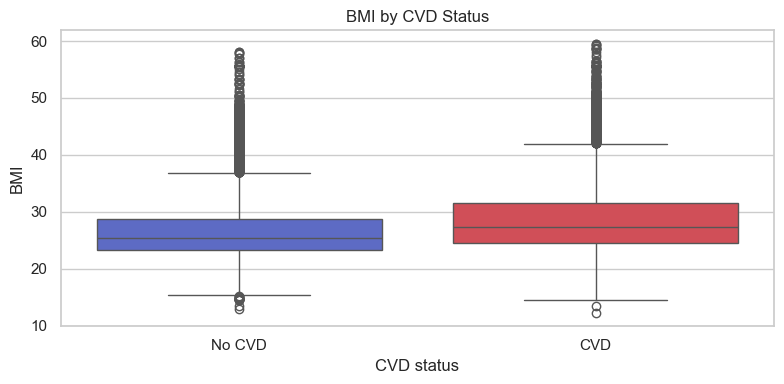

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x=label, y='BMI', hue=label, legend=False, palette=palette, ax=ax)
ax.set_title('BMI by CVD Status'); ax.set_xlabel('CVD status')
fig.tight_layout(); fig.savefig(FIG_DIR / '03_bmi_boxplot.png', dpi=150); plt.show()

### 4.4 Systolic blood pressure by CVD status

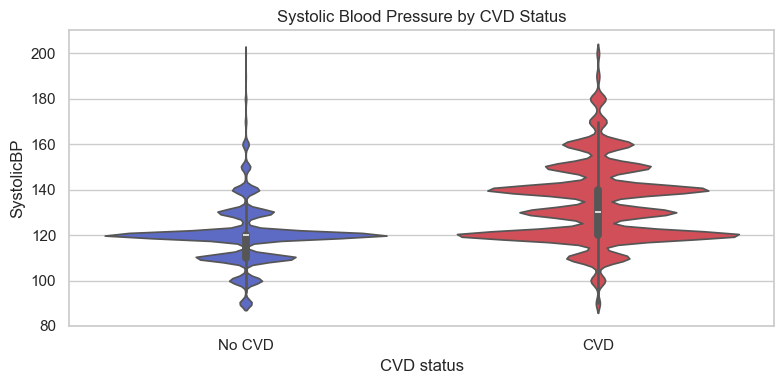

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(data=df, x=label, y='SystolicBP', hue=label, legend=False,
               palette=palette, ax=ax)
ax.set_title('Systolic Blood Pressure by CVD Status'); ax.set_xlabel('CVD status')
fig.tight_layout(); fig.savefig(FIG_DIR / '04_systolic_violin.png', dpi=150); plt.show()

### 4.5 CVD rate by cholesterol level

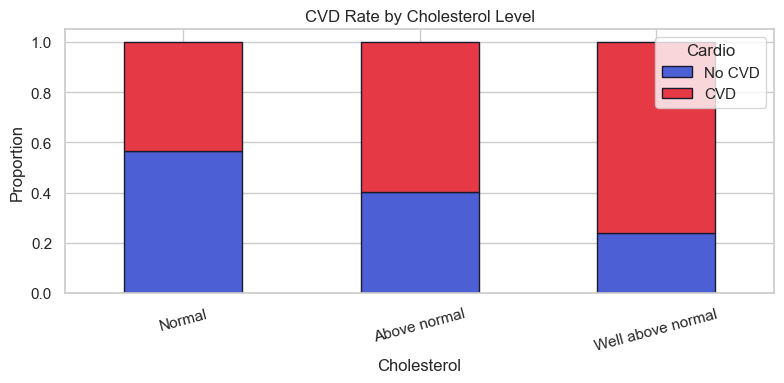

In [8]:
chol = pd.crosstab(df['Cholesterol'], label, normalize='index').reindex(
    ['Normal', 'Above normal', 'Well above normal'])
fig, ax = plt.subplots(figsize=(8, 4))
chol[['No CVD', 'CVD']].plot(kind='bar', stacked=True,
    color=[NEG_COLOR, POS_COLOR], edgecolor=EDGE, ax=ax)
ax.set_title('CVD Rate by Cholesterol Level'); ax.set_xlabel('Cholesterol')
ax.set_ylabel('Proportion'); ax.tick_params(axis='x', rotation=15)
fig.tight_layout(); fig.savefig(FIG_DIR / '05_cholesterol_vs_cardio.png', dpi=150); plt.show()

### 4.6 CVD rate by blood-pressure stage

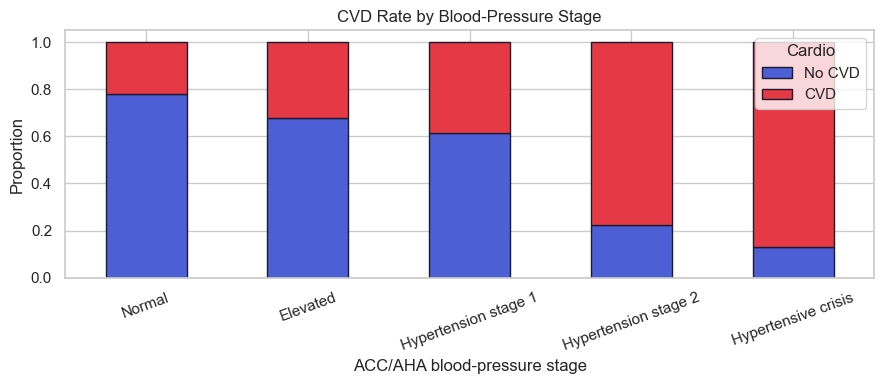

In [9]:
order = ['Normal', 'Elevated', 'Hypertension stage 1',
         'Hypertension stage 2', 'Hypertensive crisis']
bp = pd.crosstab(df['BPCategory'], label, normalize='index').reindex(order)
fig, ax = plt.subplots(figsize=(9, 4))
bp[['No CVD', 'CVD']].plot(kind='bar', stacked=True,
    color=[NEG_COLOR, POS_COLOR], edgecolor=EDGE, ax=ax)
ax.set_title('CVD Rate by Blood-Pressure Stage')
ax.set_xlabel('ACC/AHA blood-pressure stage'); ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout(); fig.savefig(FIG_DIR / '06_bp_stage_vs_cardio.png', dpi=150); plt.show()

### 4.7 Numeric feature correlation

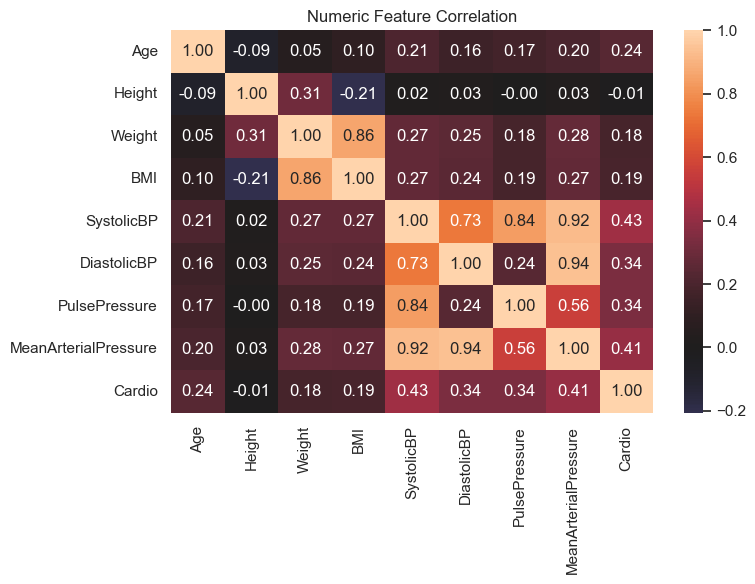

In [10]:
corr = df[NUMERIC_FEATURES + [TARGET]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='icefire', center=0, fmt='.2f', ax=ax)
ax.set_title('Numeric Feature Correlation')
fig.tight_layout(); fig.savefig(FIG_DIR / '07_correlation_heatmap.png', dpi=150); plt.show()

## Step 5 - Preprocessing Pipeline

- numeric: median imputation, then standard scaling (needed for SVM and KNN)
- categorical: most-frequent imputation, then one-hot with `handle_unknown='ignore'`

In [11]:
def build_pipeline(estimator):
    numeric = Pipeline([('imputer', SimpleImputer(strategy='median')),
                        ('scaler', StandardScaler())])
    categorical = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                            ('onehot', OneHotEncoder(handle_unknown='ignore'))])
    pre = ColumnTransformer([('num', numeric, NUMERIC_FEATURES),
                             ('cat', categorical, CATEGORICAL_FEATURES)])
    return Pipeline([('preprocess', pre), ('model', estimator)])

## Step 6 - Stratified Sample and Split

The cleaned data has ~68k rows; an RBF SVM does not scale to that, so we draw a
stratified sample of up to 15,000 rows (the classes are near-balanced) and split
80/20 stratified on the target.

In [12]:
if len(df) > MAX_TRAIN_ROWS:
    frac = MAX_TRAIN_ROWS / len(df)
    sample = (df.groupby(TARGET, group_keys=False)[df.columns]
                .apply(lambda p: p.sample(frac=frac, random_state=RANDOM_STATE))
                .reset_index(drop=True))
else:
    sample = df

X = sample[FEATURE_COLUMNS]; y = sample[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {len(X_train):,}   Test: {len(X_test):,}')

Train: 12,000   Test: 3,000


## Step 7 - Model Bake-off

Three distinct families wrapped in the same preprocessing pipeline. The SVM is the
product we deploy; KNN and XGBoost are benchmarks.

In [13]:
models = {
    'SVM (RBF)': SVC(kernel='rbf', C=2.0, gamma='scale',
                     class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=35, weights='distance'),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08,
                             subsample=0.9, colsample_bytree=0.9, eval_metric='logloss',
                             tree_method='hist', n_jobs=4, random_state=RANDOM_STATE),
}

results, fitted = [], {}
for name, est in models.items():
    pipe = build_pipeline(est); pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]; pred = (proba >= 0.5).astype(int)
    results.append({'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)})
    fitted[name] = pipe
    print(f"{name:<22s} ROC-AUC = {results[-1]['ROC-AUC']:.4f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.round(4)

SVM (RBF)              ROC-AUC = 0.7898
K-Nearest Neighbors    ROC-AUC = 0.7803
XGBoost                ROC-AUC = 0.7992


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.7377,0.7640,0.6801,0.7196,0.7992
1,SVM (RBF),0.7407,0.7668,0.6842,0.7231,0.7898
2,K-Nearest Neighbors,0.7217,0.7539,0.6498,0.6980,0.7803


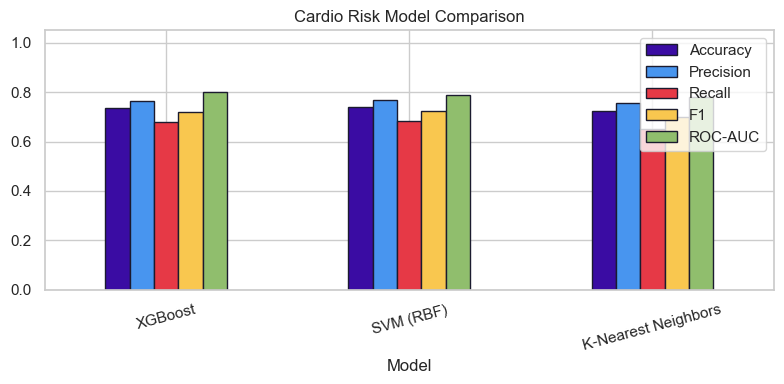

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1','ROC-AUC']].plot(
    kind='bar', color=METRIC_PALETTE, edgecolor=EDGE, ax=ax)
ax.set_title('Cardio Risk Model Comparison'); ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=15)
fig.tight_layout(); fig.savefig(FIG_DIR / '08_model_comparison.png', dpi=150); plt.show()

## Step 8 - Deploy the SVM and Tune the Threshold

We keep the SVM as the deployed screener and sweep its decision threshold from 0.10 to
0.90, choosing the F1-maximising value.

In [15]:
best_pipe = fitted['SVM (RBF)']
proba = best_pipe.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores = [f1_score(y_test, (proba >= t).astype(int)) for t in thresholds]
best_threshold = float(round(thresholds[int(np.argmax(f1_scores))], 2))
print(f'Best threshold: {best_threshold:.2f}   Best F1: {max(f1_scores):.4f}')

Best threshold: 0.32   Best F1: 0.7323


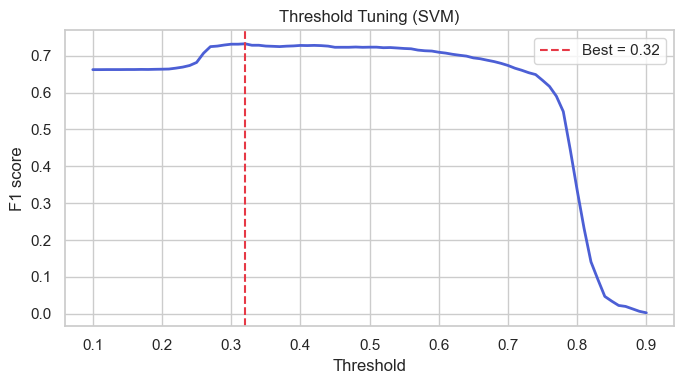

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_scores, color=NEG_COLOR, linewidth=2)
ax.axvline(best_threshold, color=POS_COLOR, linestyle='--', label=f'Best = {best_threshold:.2f}')
ax.set_title('Threshold Tuning (SVM)'); ax.set_xlabel('Threshold'); ax.set_ylabel('F1 score')
ax.legend(); fig.tight_layout()
fig.savefig(FIG_DIR / '11_threshold_tuning.png', dpi=150); plt.show()

## Step 9 - Final Evaluation

In [17]:
final_pred = (proba >= best_threshold).astype(int)
print(classification_report(y_test, final_pred, target_names=['No CVD', 'CVD']))
print('ROC-AUC:', round(roc_auc_score(y_test, proba), 4))

              precision    recall  f1-score   support

      No CVD       0.75      0.68      0.71      1515
         CVD       0.70      0.77      0.73      1485

    accuracy                           0.72      3000
   macro avg       0.72      0.72      0.72      3000
weighted avg       0.72      0.72      0.72      3000

ROC-AUC: 0.7898


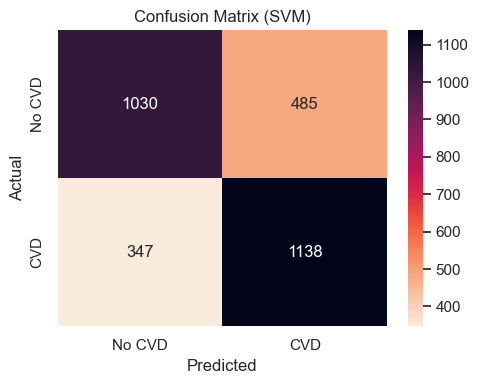

In [18]:
cm = confusion_matrix(y_test, final_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r',
            xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'], ax=ax)
ax.set_title('Confusion Matrix (SVM)'); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.tight_layout(); fig.savefig(FIG_DIR / '09_confusion_matrix.png', dpi=150); plt.show()

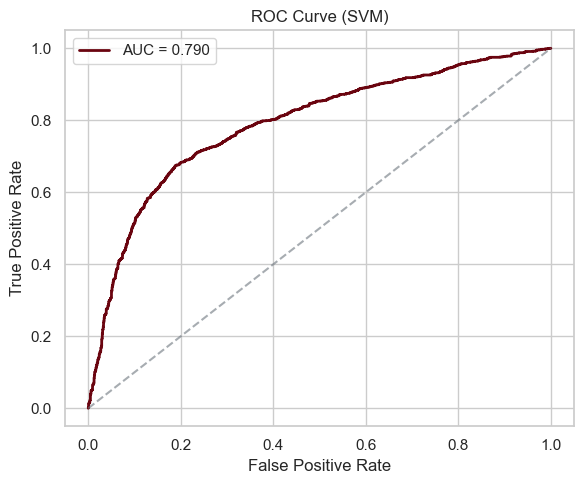

In [19]:
fpr, tpr, _ = roc_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=ACCENT, linewidth=2, label=f'AUC = {roc_auc_score(y_test, proba):.3f}')
ax.plot([0, 1], [0, 1], '--', color=NEUTRAL, alpha=0.6)
ax.set_title('ROC Curve (SVM)'); ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate'); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / '10_roc_curve.png', dpi=150); plt.show()

## Step 10 - Save the Single Deployment Bundle

Unlike a four-file layout, this project serialises everything the app needs - the
fitted pipeline, the feature order, the tuned threshold, and the UI metadata
(dropdown options, defaults, metrics) - into **one** `cardio_svm_bundle.pkl`.

In [20]:
options = {c: sorted(df[c].fillna('Unknown').astype(str).unique().tolist())
           for c in CATEGORICAL_FEATURES}
defaults = {'Age': 50, 'Height': 168, 'Weight': 74, 'BMI': 26.2,
            'SystolicBP': 120, 'DiastolicBP': 80, 'PulsePressure': 40,
            'MeanArterialPressure': 93.3}
metrics = {
    'deployed_model': 'SVM (RBF)', 'training_rows': int(len(sample)),
    'best_threshold': best_threshold,
    'accuracy': float(accuracy_score(y_test, final_pred)),
    'precision': float(precision_score(y_test, final_pred, zero_division=0)),
    'recall': float(recall_score(y_test, final_pred)),
    'f1': float(f1_score(y_test, final_pred)),
    'roc_auc': float(roc_auc_score(y_test, proba))}
metadata = {
    'project': 'Cardio-SVM Cardiovascular Risk Screener',
    'dataset': 'Cardiovascular Disease (cardio_train, 70k)',
    'rows': int(len(df)), 'columns': int(df.shape[1]), 'target': TARGET,
    'positive_class_rows': int(df[TARGET].sum()),
    'negative_class_rows': int((df[TARGET] == 0).sum()),
    'numeric_features': NUMERIC_FEATURES, 'categorical_features': CATEGORICAL_FEATURES,
    'feature_columns': FEATURE_COLUMNS, 'options': options, 'defaults': defaults,
    'model_results': results_df.to_dict(orient='records'), 'metrics': metrics}
bundle = {'pipeline': best_pipe, 'feature_columns': FEATURE_COLUMNS,
          'numeric_features': NUMERIC_FEATURES, 'categorical_features': CATEGORICAL_FEATURES,
          'threshold': best_threshold, 'metadata': metadata}
joblib.dump(bundle, 'cardio_svm_bundle.pkl')
print('Saved cardio_svm_bundle.pkl')

Saved cardio_svm_bundle.pkl


## Step 11 - Inference Demo

Reload the single bundle and score one patient exactly the way the Flask app does.

In [21]:
b = joblib.load('cardio_svm_bundle.pkl')
pipe, feats, thr = b['pipeline'], b['feature_columns'], b['threshold']
patient = {
    'Age': 58, 'Height': 165, 'Weight': 92, 'BMI': 33.8,
    'SystolicBP': 160, 'DiastolicBP': 100, 'PulsePressure': 60,
    'MeanArterialPressure': 120.0, 'Gender': 'Female',
    'Cholesterol': 'Well above normal', 'Glucose': 'Above normal',
    'Smoker': 'No', 'Alcohol': 'No', 'PhysicallyActive': 'No',
    'BMICategory': 'Obese', 'BPCategory': 'Hypertension stage 2', 'AgeGroup': '55-59'}
row = pd.DataFrame([patient])[feats]
p = float(pipe.predict_proba(row)[0, 1])
print(f'CVD probability: {p:.1%}')
print('Prediction:', 'Higher CVD risk' if p >= thr else 'Lower CVD risk')

CVD probability: 77.0%
Prediction: Higher CVD risk


## Step 12 - Conclusion

Routine vitals plus a handful of lifestyle answers carry a strong cardiovascular
signal: blood-pressure stage, age, and cholesterol dominate. The RBF SVM gives
well-separated, calibrated probabilities and ships as a single portable artifact.